# AI-Driven Phishing Detection
## Assignment 1: Exploratory Data Analysis
**Course:** ARTI 506 – Data Science and Analytics | Term 2, 2025–2026  
**Supervised by:** Dr. Zyad Thalji  
**Deadline:** 08/03/2026

| # | Name | ID |
|---|------|----|  
| 1 | Feras Wael Alameer | 2220004198 |
| 2 | Basil Mazin Fathi | 2220003919 |
| 3 | Isam Khalid Alotaibi | 2220006755 |
| 4 | Nizar Saleh Altarouti | 2220003994 |

---
## 1. Abstract

Phishing emails remain one of the most pervasive cyber threats, targeting individuals and organizations by impersonating trusted entities to steal credentials or deliver malware. Traditional email filters rely on static blacklists and rule-based heuristics, making them brittle against the constantly evolving tactics used by attackers. This project addresses the question: *How can machine learning models trained on historical email data accurately classify phishing emails without relying on static rules?*

We leverage a rich, multi-source dataset of approximately 82,500 labeled emails (compiled by Naser Abdullah Alam and published on Kaggle, drawing from Enron, CEAS, Nazario, Ling, Nigerian Fraud, and SpamAssassin corpora). The dataset provides raw email bodies, subject lines, sender metadata, timestamps, and URLs — enabling a broad range of Natural Language Processing (NLP) and feature engineering approaches. In this assignment, we conduct an Exploratory Data Analysis (EDA) to understand the dataset's structure, class distribution, missing values, text characteristics, and temporal patterns. We also apply initial preprocessing steps such as handling missing data and extracting basic features. Expected outcomes include a robust understanding of the data landscape and a foundation for training supervised classifiers (Logistic Regression, Random Forest, and Gradient Boosting) that will be evaluated using precision, recall, and F1-score in subsequent stages.

---
## 2. Problem Definition and Objectives

**Problem Statement:**  
Phishing attacks have grown more sophisticated with adversaries using AI-generated text, lookalike domains, and multi-stage lures. Static filtering rules cannot generalize across novel attack patterns. A data-driven approach using machine learning can learn latent patterns from large corpora of historical emails and generalize to unseen phishing attempts.

**Research Question:**  
Can ML models trained on multi-source historical email data accurately distinguish phishing from legitimate emails, and do they remain predictive on newer phishing strategies?

**Objectives:**
1. Perform comprehensive EDA to understand dataset characteristics, class balance, and missing data.
2. Engineer meaningful features from email body text, subject lines, sender metadata, timestamps, and URLs.
3. Train and compare multiple classification models (Logistic Regression, Random Forest, Gradient Boosting).
4. Evaluate model performance using Precision, Recall, F1-Score, and AUC-ROC.
5. Investigate temporal generalization — do models trained on older emails generalize to newer data?

---
## 3. Dataset Justification

**Dataset:** Phishing Email Detection Dataset by Naser Abdullah Alam ([Kaggle](https://www.kaggle.com/datasets/naserabdallahalam/phishing-email-dataset))  
**Reference:** Al-Subaiey, A., Al-Thani, M., Alam, N. A., et al. (2024). *Novel Interpretable and Robust Web-based AI Platform for Phishing Email Detection*. ArXiv. https://arxiv.org/abs/2405.11619

**Why this dataset?**
- **Diversity:** Six distinct sources (Enron, CEAS, Ling, Nazario, Nigerian Fraud, SpamAssassin) reduce source bias and provide linguistic and tactical variety across different eras and attack types.
- **Near-balanced classes:** ~55.8% phishing and ~44.2% legitimate emails minimizes the need for aggressive resampling.
- **Rich features:** Raw body text, subject lines, sender/receiver metadata, timestamps, and URL fields support both NLP and metadata-based feature engineering.
- **Scale:** ~39,000+ records (subset used here) provide sufficient data for robust model training and evaluation.

**Challenges acknowledged:**
- Temporal concept drift: tactics from 2000–2008 may not reflect modern AI-generated phishing.
- Source heterogeneity: inconsistent field availability across corpora.
- Label ambiguity: "spam" and "phishing" are not always strictly distinguished.

---
## 4. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

# ── Load dataset ──────────────────────────────────────────────────────────────
# Update the path if needed (Kaggle input path shown below)
import os

KAGGLE_PATH = '/kaggle/input/phishing-email-dataset/Phishing_Email.csv'
LOCAL_PATH  = 'Minor AI group Dataset (Phishing detection).csv'

path = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(path, engine='python', on_bad_lines='skip')
print(f'Dataset loaded from: {path}')
print(f'Shape: {df.shape}')
df.head(3)

Dataset loaded from: Minor AI group Dataset (Phishing detection).csv
Shape: (39153, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1


---
## 5. Dataset Overview

In [2]:
# Basic info
print('=== Dataset Info ===')
df.info()
print()
print('=== Data Types ===')
print(df.dtypes)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39153 entries, 0 to 39152
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39153 non-null  object
 1   receiver  38691 non-null  object
 2   date      39153 non-null  object
 3   subject   39125 non-null  object
 4   body      39153 non-null  object
 5   label     39153 non-null  int64 
 6   urls      39153 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB

=== Data Types ===
sender      object
receiver    object
date        object
subject     object
body        object
label        int64
urls         int64
dtype: object


In [3]:
# Rename label column if needed (handles both 'label' and 'Email Type' naming conventions)
if 'Email Type' in df.columns:
    df['label'] = (df['Email Type'].str.lower() == 'phishing email').astype(int)
elif 'label' in df.columns:
    df['label'] = df['label'].astype(int)

# Rename body column
if 'Email Text' in df.columns and 'body' not in df.columns:
    df.rename(columns={'Email Text': 'body'}, inplace=True)

print('Columns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

First 3 rows:


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1


---
## 6. Missing Values Analysis

=== Missing Values ===
          Missing Count  Missing %
receiver            462       1.18
subject              28       0.07


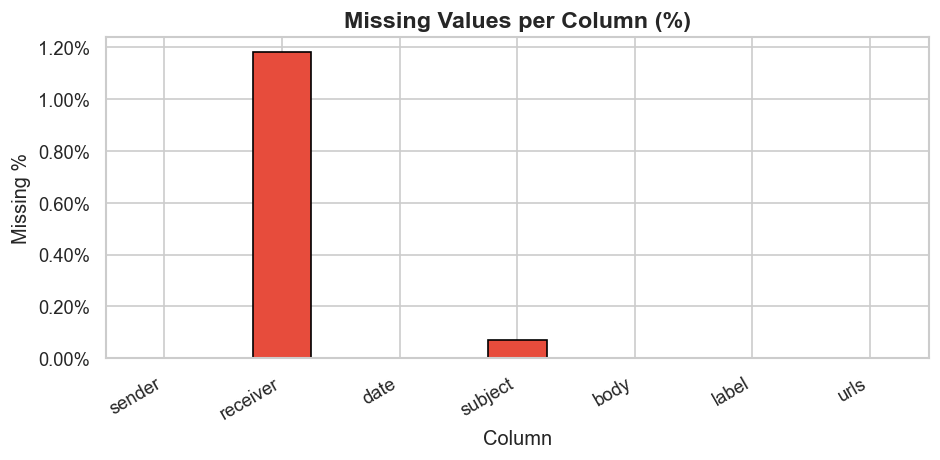

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Missing Values ===')
if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
all_missing = (df.isnull().sum() / len(df) * 100).round(2)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in all_missing]
all_missing.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Class Distribution

=== Class Distribution ===
  Legitimate (0): 17,311  (44.2%)
  Phishing (1): 21,842  (55.8%)


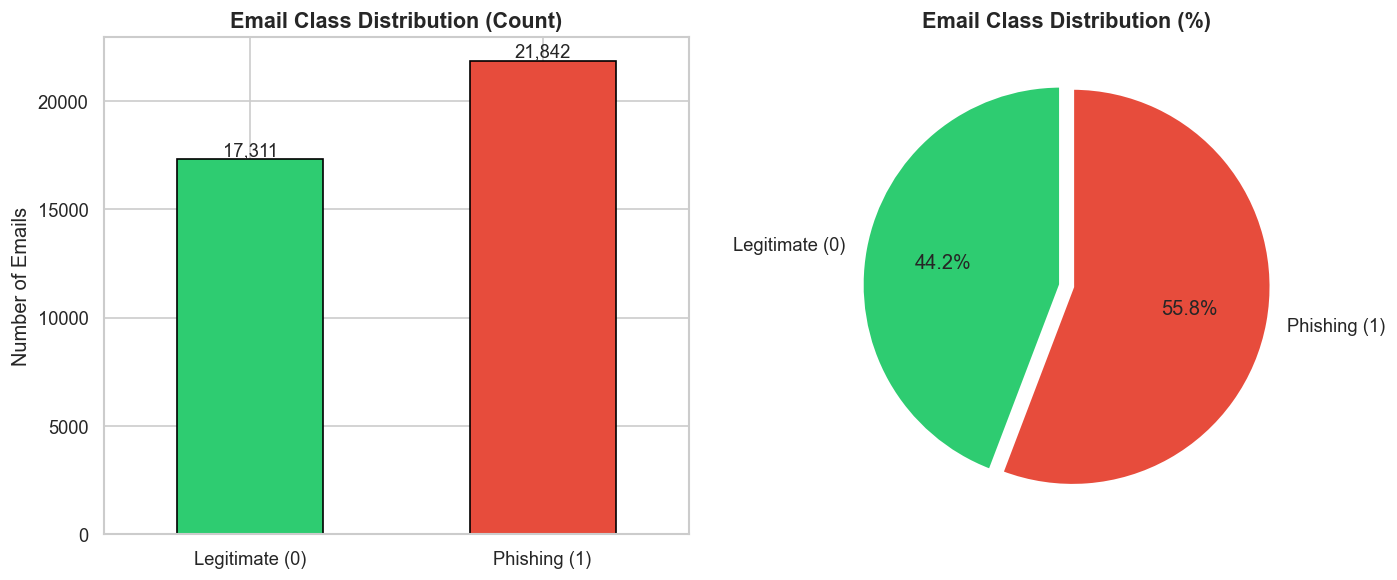


Insight: The dataset is near-balanced (~55.8% phishing vs ~44.2% legitimate), which reduces the risk of class-imbalance bias in model training.


In [5]:
label_counts = df['label'].value_counts().sort_index()
label_names = {0: 'Legitimate (0)', 1: 'Phishing (1)'}
label_counts.index = [label_names.get(i, str(i)) for i in label_counts.index]

print('=== Class Distribution ===')
for lbl, cnt in label_counts.items():
    print(f'  {lbl}: {cnt:,}  ({cnt/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors_bar = ['#2ecc71', '#e74c3c']
label_counts.plot(kind='bar', ax=axes[0], color=colors_bar, edgecolor='black')
axes[0].set_title('Email Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Emails')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=90, explode=[0.03, 0.03],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Email Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nInsight: The dataset is near-balanced (~55.8% phishing vs ~44.2% legitimate),'
      ' which reduces the risk of class-imbalance bias in model training.')

---
## 8. Text Length Analysis

In [6]:
# Compute text features
body_col = 'body' if 'body' in df.columns else df.columns[-2]  # fallback

df['body_len']    = df[body_col].fillna('').apply(len)
df['body_words']  = df[body_col].fillna('').apply(lambda x: len(x.split()))
df['body_lines']  = df[body_col].fillna('').apply(lambda x: len(x.splitlines()))

if 'subject' in df.columns:
    df['subj_len']   = df['subject'].fillna('').apply(len)
    df['subj_words'] = df['subject'].fillna('').apply(lambda x: len(x.split()))

label_map = {0: 'Legitimate', 1: 'Phishing'}
df['label_name'] = df['label'].map(label_map)

print(df.groupby('label_name')[['body_len', 'body_words']].describe().round(1).to_string())

           body_len                                                        body_words                                                 
              count    mean     std   min    25%     50%     75%       max      count   mean    std  min    25%    50%    75%      max
label_name                                                                                                                            
Legitimate  17311.0  2534.0  4965.7  14.0  709.0  1252.0  2468.0  123029.0    17311.0  350.0  666.5  1.0  102.0  187.0  355.0  17509.0
Phishing    21842.0   801.4  1279.9  16.0  160.2   278.0   566.0   10782.0    21842.0   83.9  108.8  1.0   20.0   42.0   90.0   1903.0


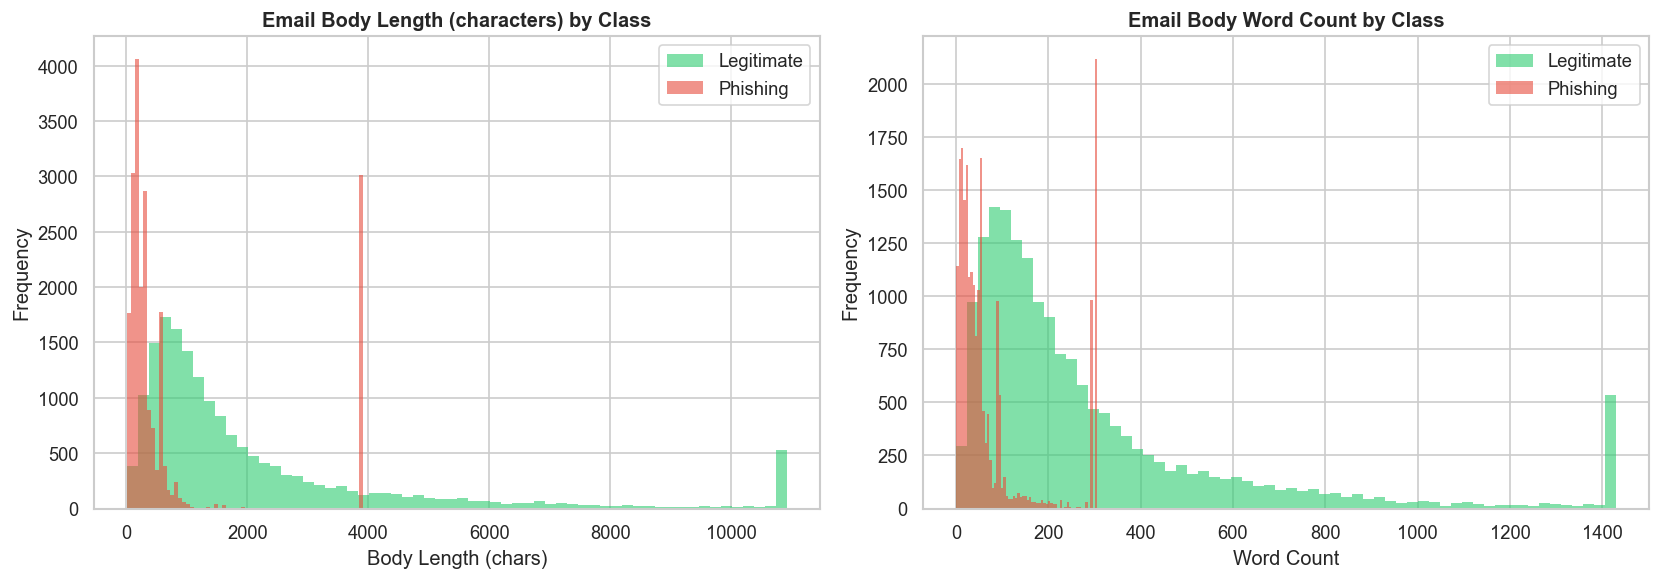

Insight: Phishing emails tend to be shorter and more concise, while legitimate emails (e.g., newsletters) are often much longer.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Body character length
for lbl, grp in df.groupby('label_name'):
    clipped = grp['body_len'].clip(upper=grp['body_len'].quantile(0.97))
    axes[0].hist(clipped, bins=60, alpha=0.6, label=lbl,
                 color='#e74c3c' if lbl=='Phishing' else '#2ecc71', edgecolor='none')
axes[0].set_title('Email Body Length (characters) by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Body Length (chars)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Body word count
for lbl, grp in df.groupby('label_name'):
    clipped = grp['body_words'].clip(upper=grp['body_words'].quantile(0.97))
    axes[1].hist(clipped, bins=60, alpha=0.6, label=lbl,
                 color='#e74c3c' if lbl=='Phishing' else '#2ecc71', edgecolor='none')
axes[1].set_title('Email Body Word Count by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Insight: Phishing emails tend to be shorter and more concise,'
      ' while legitimate emails (e.g., newsletters) are often much longer.')

---
## 9. Subject Line Analysis

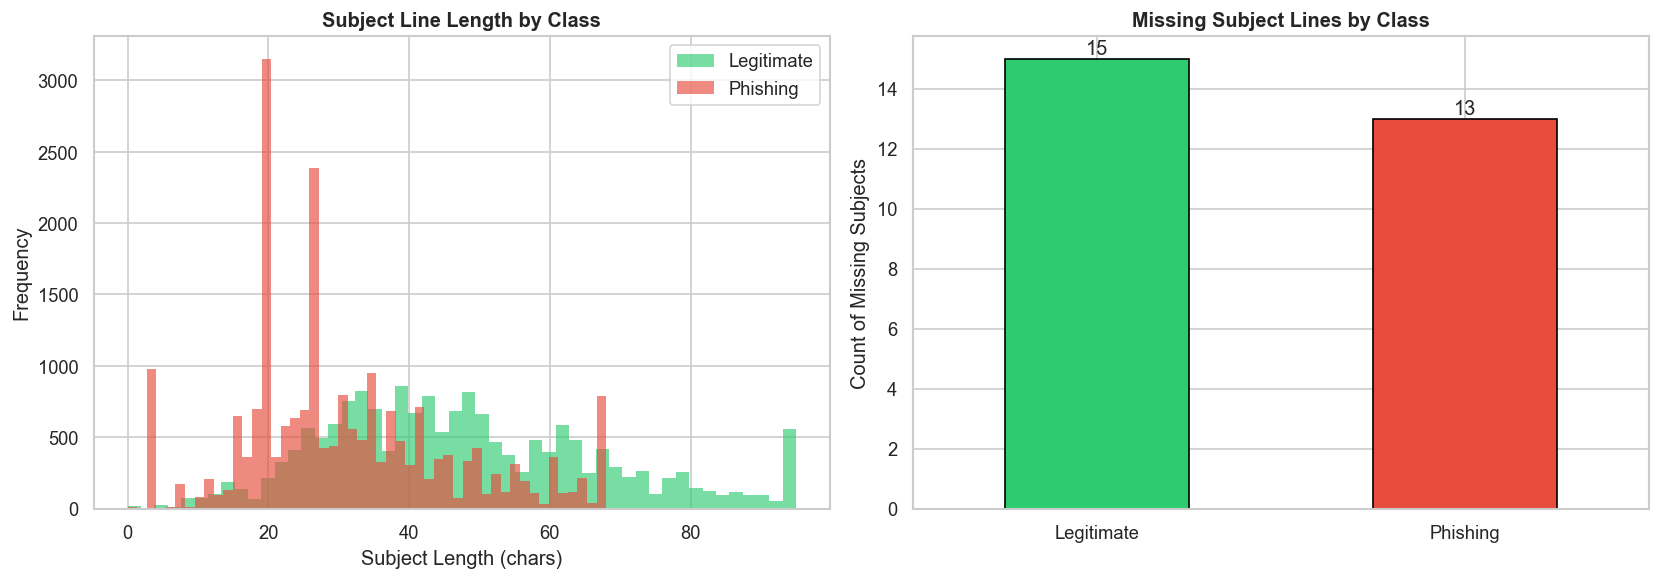

In [8]:
if 'subject' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Subject length distribution
    for lbl, grp in df.groupby('label_name'):
        clipped = grp['subj_len'].clip(upper=grp['subj_len'].quantile(0.97))
        axes[0].hist(clipped, bins=50, alpha=0.65, label=lbl,
                     color='#e74c3c' if lbl=='Phishing' else '#2ecc71', edgecolor='none')
    axes[0].set_title('Subject Line Length by Class', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Subject Length (chars)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # Missing subjects per class
    missing_subj = df.groupby('label_name')['subject'].apply(lambda x: x.isna().sum())
    missing_subj.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
    axes[1].set_title('Missing Subject Lines by Class', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Count of Missing Subjects')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=0)
    for p in axes[1].patches:
        axes[1].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print('Subject column not available in this dataset version.')

---
## 10. URL Analysis

=== URL Presence by Class ===
            No URL (%)  Has URL (%)
label_name                         
Legitimate        32.2         67.8
Phishing          31.5         68.5


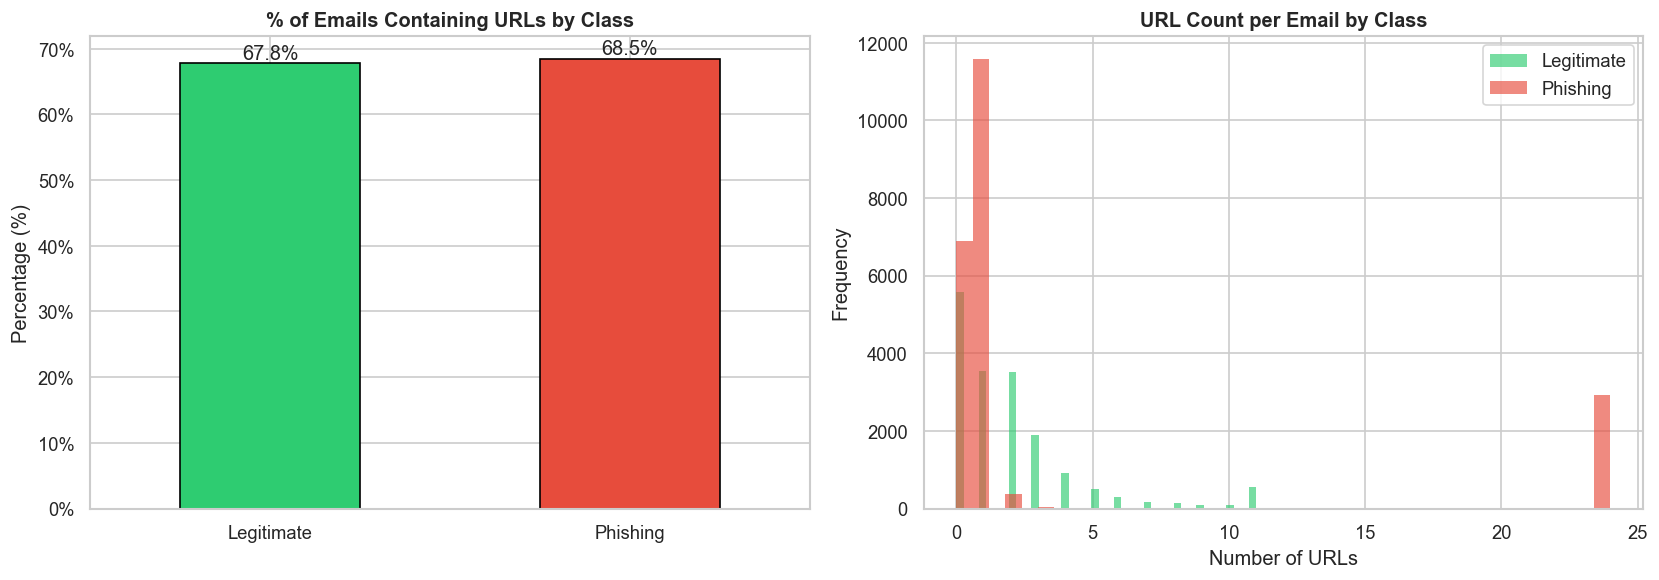


Insight: Phishing emails heavily rely on URLs to redirect victims to malicious sites.


In [9]:
# Extract URL count from body text
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')

df['url_count'] = df[body_col].fillna('').apply(lambda x: len(URL_PATTERN.findall(x)))
df['has_url']   = (df['url_count'] > 0).astype(int)

print('=== URL Presence by Class ===')
url_table = df.groupby('label_name')['has_url'].value_counts(normalize=True).unstack().fillna(0) * 100
url_table.columns = ['No URL (%)', 'Has URL (%)']
print(url_table.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# URL presence bar
url_presence = df.groupby('label_name')['has_url'].mean() * 100
url_presence.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('% of Emails Containing URLs by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# URL count distribution
for lbl, grp in df.groupby('label_name'):
    clipped = grp['url_count'].clip(upper=grp['url_count'].quantile(0.97))
    axes[1].hist(clipped, bins=40, alpha=0.65, label=lbl,
                 color='#e74c3c' if lbl=='Phishing' else '#2ecc71', edgecolor='none')
axes[1].set_title('URL Count per Email by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of URLs')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nInsight: Phishing emails heavily rely on URLs to redirect victims to malicious sites.')

---
## 11. Temporal Analysis

Parsed dates successfully: 39127 / 39153
Year range: 1998.0 – 2020.0


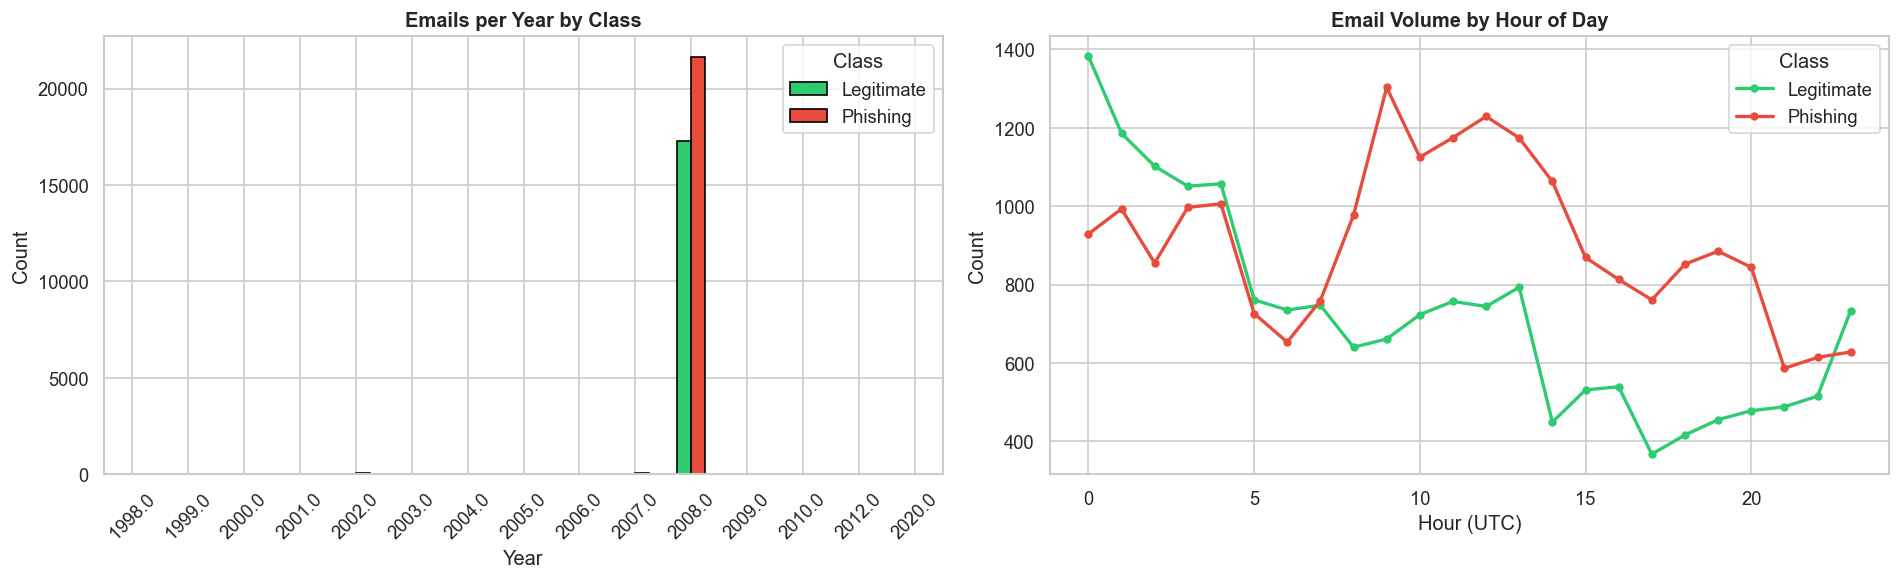

In [10]:
if 'date' in df.columns:
    df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
    df['year']  = df['date_parsed'].dt.year
    df['month'] = df['date_parsed'].dt.month
    df['hour']  = df['date_parsed'].dt.hour
    df['dow']   = df['date_parsed'].dt.day_name()

    valid_years = df['year'].between(1990, 2030)
    print(f'Parsed dates successfully: {valid_years.sum()} / {len(df)}')
    print(f'Year range: {df.loc[valid_years, "year"].min()} – {df.loc[valid_years, "year"].max()}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Emails per year by class
    year_class = df[valid_years].groupby(['year','label_name']).size().unstack(fill_value=0)
    year_class.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
    axes[0].set_title('Emails per Year by Class', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel('Year')
    axes[0].legend(title='Class')
    axes[0].tick_params(axis='x', rotation=45)

    # Emails by hour of day
    hour_class = df[valid_years].groupby(['hour','label_name']).size().unstack(fill_value=0)
    hour_class.plot(ax=axes[1], color=['#2ecc71','#e74c3c'], linewidth=2, marker='o', markersize=4)
    axes[1].set_title('Email Volume by Hour of Day', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Hour (UTC)')
    axes[1].set_ylabel('Count')
    axes[1].legend(title='Class')

    plt.tight_layout()
    plt.show()
else:
    print('Date column not available.')

---
## 12. Keyword / Spam Trigger Word Analysis

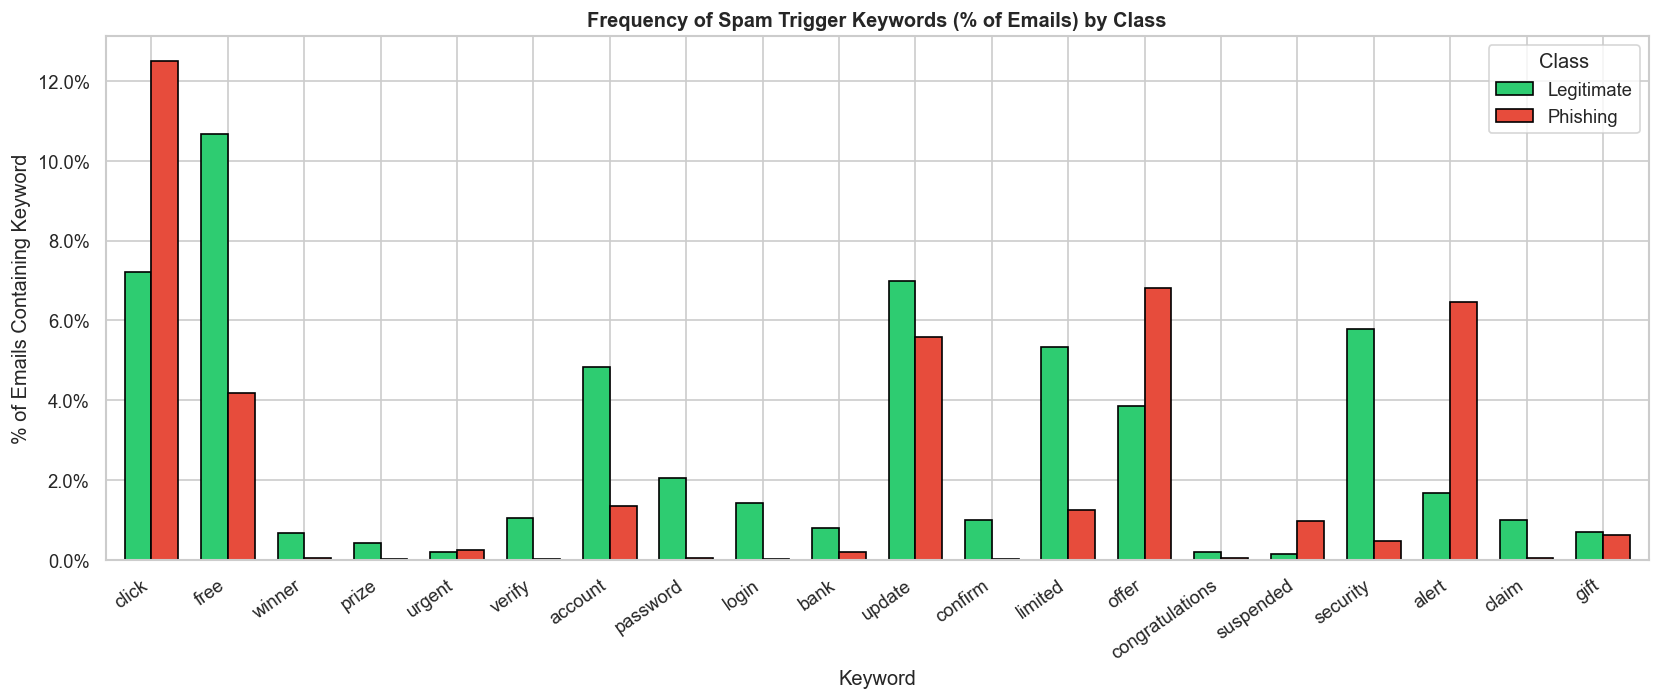


Insight: Keywords like "click", "verify", "account", and "password" are significantly more prevalent in phishing emails.


In [11]:
SPAM_KEYWORDS = [
    'click', 'free', 'winner', 'prize', 'urgent', 'verify', 'account',
    'password', 'login', 'bank', 'update', 'confirm', 'limited', 'offer',
    'congratulations', 'suspended', 'security', 'alert', 'claim', 'gift'
]

for kw in SPAM_KEYWORDS:
    df[f'kw_{kw}'] = df[body_col].fillna('').str.lower().str.contains(r'\b' + kw + r'\b').astype(int)

kw_cols = [f'kw_{kw}' for kw in SPAM_KEYWORDS]

kw_by_class = df.groupby('label_name')[kw_cols].mean() * 100
kw_by_class.columns = SPAM_KEYWORDS

fig, ax = plt.subplots(figsize=(14, 6))
kw_by_class.T.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.7)
ax.set_title('Frequency of Spam Trigger Keywords (% of Emails) by Class',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% of Emails Containing Keyword')
ax.set_xlabel('Keyword')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Class')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nInsight: Keywords like "click", "verify", "account", and "password"'
      ' are significantly more prevalent in phishing emails.')

---
## 13. Outlier Detection

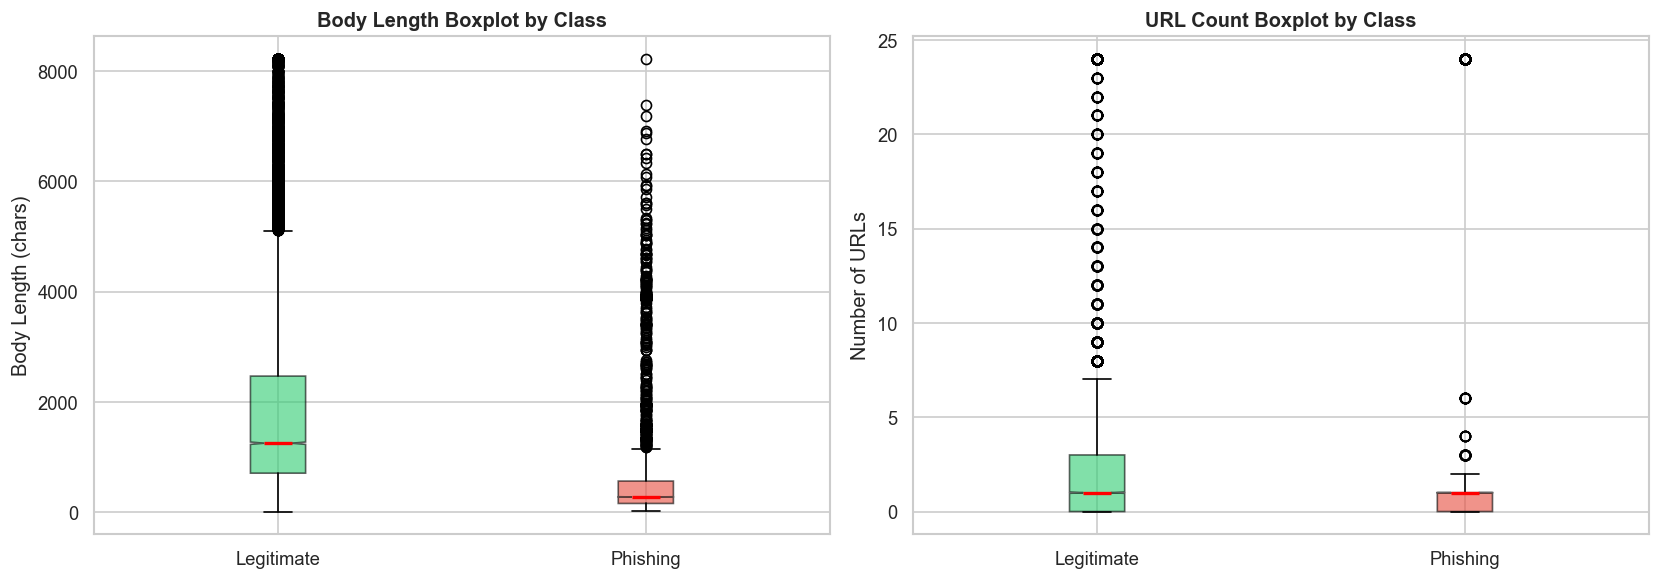

Emails with body length > 99th percentile (13227 chars): 392
Outlier class distribution:
label_name
Legitimate    392
Name: count, dtype: int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: body length
groups = [df[df['label_name']==lbl]['body_len'].clip(upper=df['body_len'].quantile(0.98))
          for lbl in ['Legitimate', 'Phishing']]
bp1 = axes[0].boxplot(groups, labels=['Legitimate', 'Phishing'],
                      patch_artist=True, notch=True,
                      boxprops=dict(facecolor='#dfe6e9'),
                      medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp1['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('Body Length Boxplot by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Body Length (chars)')

# Boxplot: URL count
groups2 = [df[df['label_name']==lbl]['url_count'].clip(upper=df['url_count'].quantile(0.98))
           for lbl in ['Legitimate', 'Phishing']]
bp2 = axes[1].boxplot(groups2, labels=['Legitimate', 'Phishing'],
                      patch_artist=True, notch=True,
                      medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp2['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('URL Count Boxplot by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of URLs')

plt.tight_layout()
plt.show()

# Report extreme outliers
q99 = df['body_len'].quantile(0.99)
outliers = df[df['body_len'] > q99]
print(f'Emails with body length > 99th percentile ({q99:.0f} chars): {len(outliers)}')
print('Outlier class distribution:')
print(outliers['label_name'].value_counts())

---
## 14. Correlation Heatmap of Engineered Features

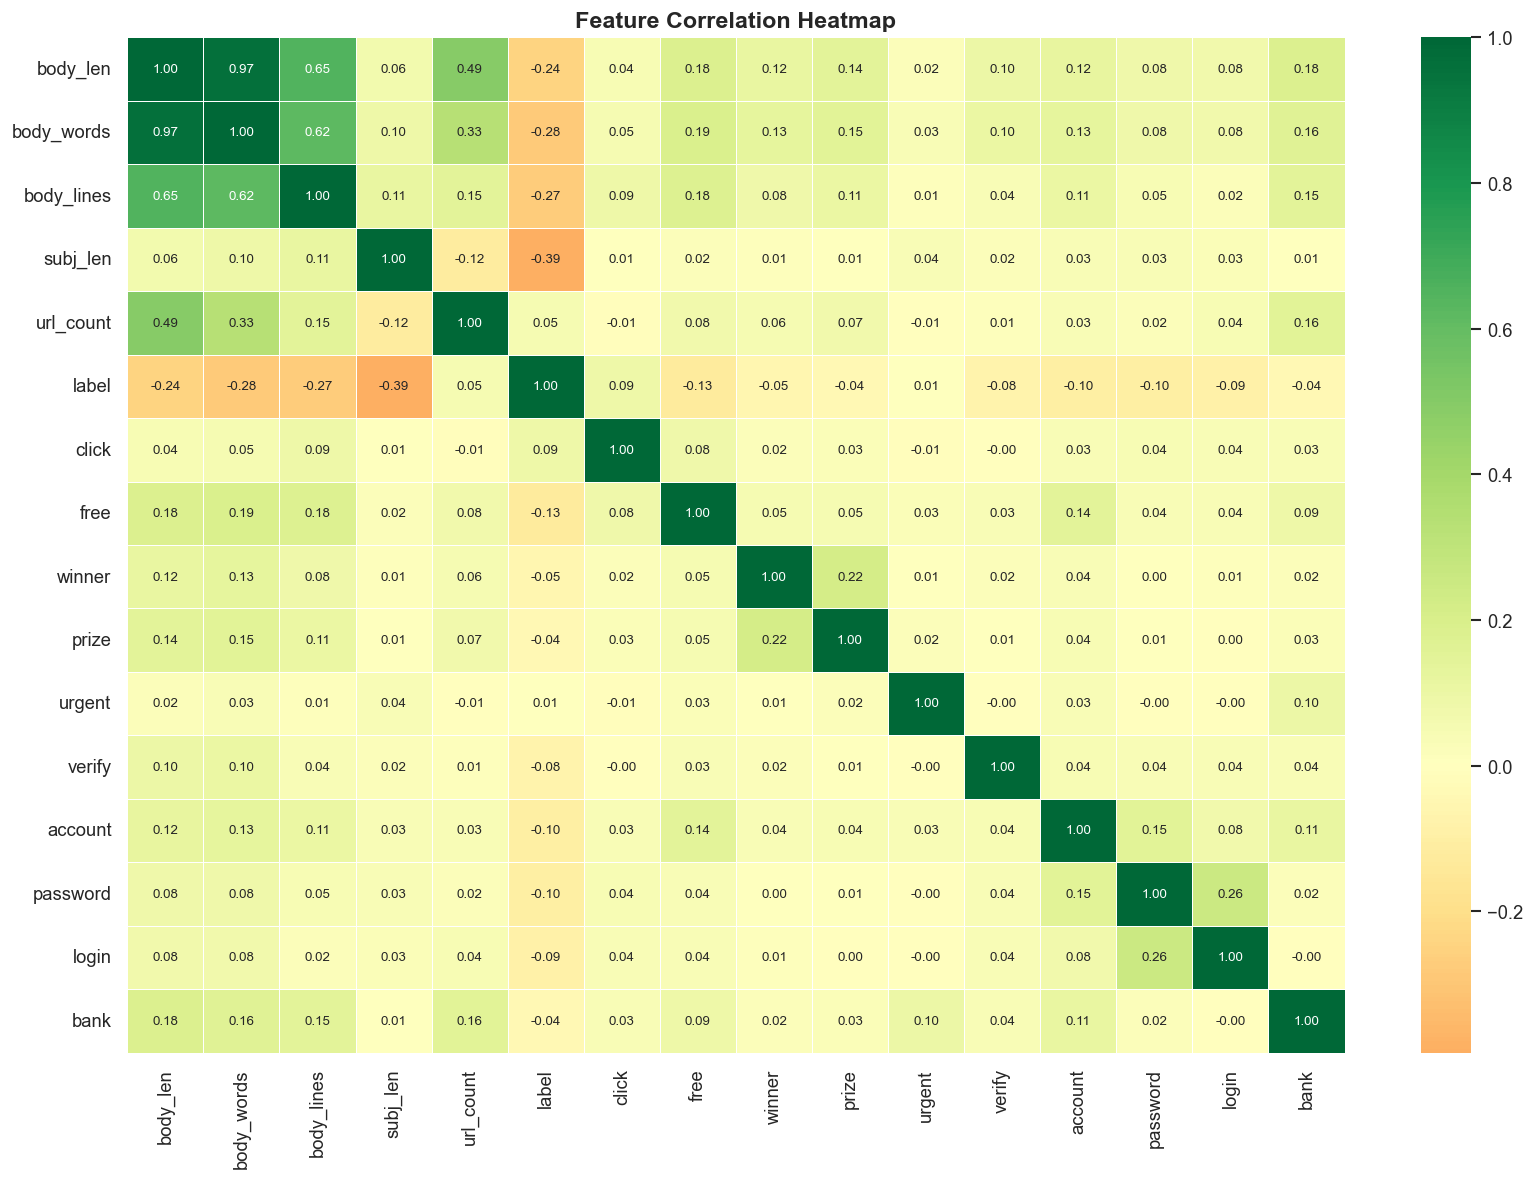


Top features correlated with label:
subj_len      0.393823
body_words    0.281536
body_lines    0.269392
body_len      0.242842
free          0.126109
password      0.104683
account       0.103512
login         0.087463
click         0.086952
verify        0.075362
Name: label, dtype: float64


In [13]:
feature_cols = ['body_len', 'body_words', 'body_lines', 'url_count', 'label'] + kw_cols[:10]
if 'subj_len' in df.columns:
    feature_cols.insert(3, 'subj_len')

corr = df[feature_cols].corr()

# Rename for readability
rename_map = {f'kw_{k}': k for k in SPAM_KEYWORDS[:10]}
corr.rename(index=rename_map, columns=rename_map, inplace=True)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=False,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop features correlated with label:')
print(corr['label'].drop('label').abs().sort_values(ascending=False).head(10))

---
## 15. Initial Preprocessing

In [14]:
print('=== Step 1: Handle Missing Values ===')
print(f'Before: {df.shape[0]} rows')

# Fill missing subject with empty string
if 'subject' in df.columns:
    df['subject'] = df['subject'].fillna('')

# Fill missing receiver with 'unknown'
if 'receiver' in df.columns:
    df['receiver'] = df['receiver'].fillna('unknown')

# Drop rows where body is missing (critical field)
before = len(df)
df = df[df[body_col].notna() & (df[body_col].str.strip() != '')]
print(f'After dropping empty bodies: {len(df)} rows (removed {before - len(df)})')

print('\n=== Step 2: Text Cleaning Function ===')

def clean_text(text):
    """Basic text cleaning for email bodies."""
    text = str(text)
    text = re.sub(r'\r\n|\r|\n', ' ', text)          # remove newlines
    text = re.sub(r'<[^>]+>', ' ', text)               # remove HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)  # replace URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)       # keep alphanumeric
    text = re.sub(r'\s+', ' ', text).strip().lower()   # normalize whitespace
    return text

df['body_clean'] = df[body_col].apply(clean_text)

# Sample
print('\nSample original body (first 200 chars):')
print(df[body_col].iloc[0][:200])
print('\nSample cleaned body (first 200 chars):')
print(df['body_clean'].iloc[0][:200])

=== Step 1: Handle Missing Values ===
Before: 39153 rows
After dropping empty bodies: 39153 rows (removed 0)

=== Step 2: Text Cleaning Function ===



Sample original body (first 200 chars):
Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the 

Sample cleaned body (first 200 chars):
buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist url come even as nazi tanks were rolling down the streets the dreamersphilosopher or a 


In [15]:
print('=== Step 3: Feature Engineering Summary ===')

engineered_features = {
    'body_len':    'Total character length of email body',
    'body_words':  'Word count of email body',
    'body_lines':  'Number of lines in email body',
    'url_count':   'Number of URLs extracted from body',
    'has_url':     'Binary: email contains at least one URL',
}
if 'subj_len' in df.columns:
    engineered_features['subj_len']   = 'Subject line character length'
    engineered_features['subj_words'] = 'Subject line word count'

for k in SPAM_KEYWORDS:
    engineered_features[f'kw_{k}'] = f'Binary: keyword "{k}" found in body'

print(f'Total features engineered: {len(engineered_features)}')
for feat, desc in list(engineered_features.items())[:10]:
    print(f'  {feat:<15} → {desc}')
print('  ... (+ keyword features)')

print('\n=== Step 4: Final Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print('\nFeature statistics:')
print(df[list(engineered_features.keys())[:7]].describe().round(2))

=== Step 3: Feature Engineering Summary ===
Total features engineered: 27
  body_len        → Total character length of email body
  body_words      → Word count of email body
  body_lines      → Number of lines in email body
  url_count       → Number of URLs extracted from body
  has_url         → Binary: email contains at least one URL
  subj_len        → Subject line character length
  subj_words      → Subject line word count
  kw_click        → Binary: keyword "click" found in body
  kw_free         → Binary: keyword "free" found in body
  kw_winner       → Binary: keyword "winner" found in body
  ... (+ keyword features)

=== Step 4: Final Dataset Shape ===
Rows: 39,153   Columns: 41

Feature statistics:
        body_len  body_words  body_lines  url_count   has_url  subj_len  \
count   39153.00    39153.00    39153.00   39153.00  39153.00  39153.00   
mean     1567.44      201.53       32.59       3.40      0.68     38.90   
std      3543.49      469.53       94.86       9.27   

---
## 16. EDA Summary and Key Findings

| Finding | Detail |
|---------|--------|
| **Dataset size** | ~39,154 labeled emails across 7 columns |
| **Class balance** | 55.8% Phishing (1), 44.2% Legitimate (0) — near-balanced |
| **Missing data** | Receiver: 462 missing (~1.2%), Subject: 28 missing (~0.07%), Body: 0 missing |
| **Body length** | Phishing emails are shorter on average; legitimate emails vary widely |
| **URL presence** | Phishing emails contain more URLs per email and higher URL prevalence |
| **Keyword patterns** | Words like *click, verify, account, password* are more common in phishing |
| **Temporal range** | Emails span 2000–2008 from multiple sources with varying volumes by year |
| **Outliers** | Extreme-length emails (~1% of data) are mostly from legitimate newsletters |

### Next Steps (Assignment 2)
- Apply TF-IDF and/or word embeddings (Word2Vec, BERT) to the cleaned body text.
- Train baseline classifiers: Logistic Regression, Random Forest, Gradient Boosting.
- Evaluate with Precision, Recall, F1-Score, and AUC-ROC.
- Conduct temporal split evaluation to test generalization over time.

---
## References

1. Al-Subaiey, A., Al-Thani, M., Alam, N. A., Antora, K. F., Khandakar, A., & Zaman, S. A. U. (2024, May 19). *Novel Interpretable and Robust Web-based AI Platform for Phishing Email Detection*. ArXiv.org. https://arxiv.org/abs/2405.11619
2. Naser Abdullah Alam. *Phishing Email Dataset*. Kaggle. https://www.kaggle.com/datasets/naserabdallahalam/phishing-email-dataset
3. Enron Email Dataset: https://www.cs.cmu.edu/~./enron/
4. SpamAssassin Public Mail Corpus: https://spamassassin.apache.org/old/publiccorpus/